<h1 style="font-size:30px;">Implementing a CNN in PyTorch</h1>

In this notebook, we’ll learn how to implement a Convolutional Neural Network (CNN) from scratch using PyTorch. Here, we show a custom CNN architecture with fewer layers. We will learn how to model this architecture and train it on a small dataset called [10 Monkey Species](https://www.kaggle.com/slothkong/10-monkey-species).


<center><img src='https://www.dropbox.com/scl/fi/e4541jejdlxzny3vrgw24/Monkey_architecture-updated.png?rlkey=4c3jm0kgzwm4txn1mbewqbox9&st=vq1lb2nt&dl=1' ></center>

## Table of Content

* [1. Download and Extract the Dataset](#1.-Download-and-Extract-the-Dataset)
* [2. Dataset and Training Configuration Parameters](#2.-Dataset-and-Training-Configuration-Parameters)
* [3. Dataset Preprocessing](#3.-Dataset-Preprocessing)
* [4. CNN Model Implementation in PyTorch](#4-CNN-Model-Implementation-in-PyTorch)
* [5. Model Training and Evaluation](#5.-Model-Training-and-Evaluation)
* [6. Saving and Loading Best Model Weights](#6.-Saving-and-Loading-Best-Model-Weights)
* [7. Inference](#7.-Inference)
* [8. Conclusion](#8.-Conclusion)

## Import Dependencies

In [3]:
!pip install -q torchinfo # not available in colab

In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import time
import numpy as np
import random
import warnings
import os
from tqdm import tqdm

import pandas as pd

%matplotlib inline
warnings.filterwarnings("ignore")

In [5]:
#Set seed for reproducibilty for the results. => Goal of the seed.
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
       torch.cuda.manual_seed(seed)
       torch.cuda.manual_seed_all(seed)
       torch.backends.cudnn.deterministic = True
       torch.backends.cudnn.benchmark = True

set_seed(42)

## 1. Download and Extract the Dataset

<center><img src='https://www.dropbox.com/scl/fi/m5kngoab3d9p6ajbffwr9/Monkey-Species-Dataset.jpg?rlkey=t62unc200y259ltk5kqlxa9cj&st=334vllym&dl=1' width=500 height=500></center>



In [6]:
# note: download from the URL via wget.
!wget -q "https://www.dropbox.com/s/45jdd8padeyjq6t/10_Monkey_Species.zip?dl=1" -O "10_Monkey_Species.zip"

In [7]:
!unzip -q "10_Monkey_Species.zip"

## 2. Dataset and Training Configuration Parameters

Before we describe the model implementation and training, we’re going to apply a little more structure to our training process by using the `dataclasses` module in python to create simple `DatasetConfig` and `TrainingConfig` classes to organize several data and training configuration parameters. This allows us to create data structures for configuration parameters, as shown below. The benefit of doing this is that we have a single place to go to make any desired changes.

In [35]:
@dataclass(frozen=True)
class TrainingConfig:
      ''' Configuration for Training '''
      batch_size: int = 32 # note: we need the batch to avoid loading the huge amount of data into CPU memory. We are talking about millions of data.
      num_epochs: int = 50 # nr. of iterations over all the dataset. | going once is not enough, since as far as it goes through the dataset again and again it improves.
      learning_rate: float = 1e-4 # just like knobs(handles). It's random at beginning, but It's out job to set it. | used in backpropagation to update the weights.

      log_interval: int = 1 # how often log the response. | 1 = everytime we go through the data.
      test_interval: int = 1
      data_root: int = "./"
      num_workers: int = 5
      device: str = "cuda"

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print("Available Device: ", DEVICE)

Available Device:  cuda


<h3 style="font-size:30px;">2.1. Load Custom Datasets in PyTorch</h3>

Till now, we have experimented with datasets like Fashion MNIST available with the PyTorch Torchvision library.

In this notebook, we will see how to load raw images present in a folder.

In the real world, we have need the manage the structure and preprocessing of the dataset on our own.

To illustrate a few preprocessing, we have chosen the [10 Monkey Species](https://www.kaggle.com/slothkong/10-monkey-species) dataset from Kaggle. You can download the data from [here](https://www.kaggle.com/slothkong/10-monkey-species/download). You need to extract data. We have already uploaded the extracted data in the lab.

Each folder contains 10 subforders labeled as n0~n9, each corresponding a species form Wikipedia's monkey cladogram. Images are 400x300 px or larger and JPEG format (almost 1400 images). Images were downloaded with help of the googliser open source code.

**Label mapping:**

| Label | Monkey Species |
| --- | --- |
| n0 | alouatta_palliata |
| n1 | erythrocebus_patas |
| n2 | cacajao_calvus |
| n3 | macaca_fuscata |  
| n4 | cebuella_pygmea |
| n5 | cebus_capucinus |
| n6 | mico_argentatus |
| n7 | saimiri_sciureus |
| n8 | aotus_nigriceps |
| n9 | trachypithecus_johnii |


**Extracted Folder structure:**

```
data_root
├── training
│   └── training
│       ├── n0
│       ├── n1
│       ├── n2
│       ├── n3
│       ├── n4
│       ├── n5
│       ├── n6
│       ├── n7
│       ├── n8
│       └── n9
└── validation
    └── validation
        ├── n0
        ├── n1
        ├── n2
        ├── n3
        ├── n4
        ├── n5
        ├── n6
        ├── n7
        ├── n8
        └── n9

```

`data_root/training/training` has `n0-n9` folders; each folder has images of the corresponding class. Similarly, `data_root/validation/validation` has `n0-n9` folders.

note: If we ask NL to test on the trained data, It is so powerful and try to memorise everything and gives us 0 error which is not useful.
That's why we need validation set.

In [9]:
train_root = os.path.join("10_Monkey_Species", "training", "training")
val_root = os.path.join(train_config.data_root, "10_Monkey_Species", "validation", "validation")

In [10]:
df = pd.read_csv(os.path.join("10_Monkey_Species","monkey_labels.txt"), sep=",", header=None)
df.columns = ["Label", "Latin Name", "Common Name", "Train Images", "Validation Images"]
df['Latin Name'] = df['Latin Name'].str.replace("\t", " ")
df[1:]

,Label,Latin Name,Common Name,Train Images,Validation Images
1,n0,alouatta_palliata,mantled_howler,131,26
2,n1,erythrocebus_patas,patas_monkey,139,28
3,n2,cacajao_calvus,bald_uakari,137,27
4,n3,macaca_fuscata,japanese_macaque,152,30
5,n4,cebuella_pygmea,pygmy_marmoset,131,26
6,n5,cebus_capucinus,white_headed_capuchin,141,28
7,n6,mico_argentatus,silvery_marmoset,132,26
8,n7,saimiri_sciureus,common_squirrel_monkey,142,28
9,n8,aotus_nigriceps,black_headed_night_monkey,133,27
10,n9,trachypithecus_johnii,nilgiri_langur,132,26


## 3. Dataset Preprocessing

Here, we normalize the image data to the range `[0,1]` with `mean` and `std` of our Dataset. This is very common when working with image data which helps the model train more efficiently.

In [11]:
mean = [0.4368, 0.4336, 0.3294]  #mean and std of this Monkey Species dataset
std = [0.2457, 0.2413, 0.2447]
# note: both are given to us.
# note: If they are not provided, we could use one tool to have them.
# note: both are done due to normalization purposes:
# MEAN helps us, rmeoves the brightness in images.
# Standard deviation removes the contrast element.
# => If two images are at the same scene but have different contrast, first subtract by MEAN then divide by Standard deviation => eliminate brightness changes and contrast changes.
# GOAL: images look more uniform.

img_size = (224,224) # why this tool? because AlexNet in 2012 used this size before (historical reasons).

preprocess = transforms.Compose(
    [
        transforms.Resize(img_size, antialias=True), # antialias imprive the image quality, even though it is computationaly heavy.
        transforms.ToTensor() # 2D means matrix, but multi-dimensional means Tensor.
    ]
)

In [12]:
# Data augmentation proces
# the more variation of data e.g. horizontally fliping image you give, the better results you get.


common_transforms = transforms.Compose(
    [
        preprocess,
        transforms.Normalize(mean=mean,std=std)
    ]
)

train_transforms = transforms.Compose(
    [
        preprocess,
        transforms.RandomHorizontalFlip(), # note: the actual image and fliped image are different to us, but to machine learning, they are two different things.


        transforms.RandomErasing(p=0.4), # note: by obscuring some parts of the image, we are making the model more robust. ex: earasing some part of the image at different parts to make thr model more robust by identifying it.
        transforms.RandomApply([ # rotation, translation of image.
        transforms.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75)),
         ], p =0.1),

        transforms.Normalize(mean = mean,std = std) # normalizing the image by means of mean and standard deviation.
    ]
)


### 3.1. DataLoader Preparation



**PyTorch has inbuilt functionality (`torchvision.datasets.ImageFolder` class) to load such structured image folders:**

```
torchvision.datasets.ImageFolder(root, transform=None, target_transform=None, loader=<function default_loader>, is_valid_file=None)
```

This is a generic data loader where the images are arranged in this way:

```
root/n0/xxx.png
root/n0/xxy.jpg
root/n0/xxz.png

root/n1/123.jpg
root/n1/nsdf3.png
root/n1/asd932_.png

    :
    :
    
root/n9/1b23.jpg
root/n9/nsasdf3.png
root/n9/as2wdd932_.png
    
```

Parameters:

- `root` (string) - Root directory path.

- `transform` (callable, optional) - A function/transform that takes in an PIL image and returns a transformed version. E.g, `transforms.RandomCrop`.

- `target_transform` (callable, optional) - A function/transform that takes in the target and transforms it.

- `loader` (callable, optional) - A function to load an image given its path.

- `is_valid_file` - A function that takes path of an Image file and check if the file is a valid file (used to check of corrupt files).

Find more details [here](https://pytorch.org/docs/stable/torchvision/datasets.html#torchvision.datasets.ImageFolder).


In [13]:
#Apply augmentations to the training dataset
train_data = datasets.ImageFolder(root = train_root, transform = train_transforms)

# The validation dataset should have only common transforms like Resize, ToTensor and Normalize.
val_data = datasets.ImageFolder(root=val_root, transform = common_transforms)
train_data.classes

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [14]:
train_data.class_to_idx

{'n0': 0,
 'n1': 1,
 'n2': 2,
 'n3': 3,
 'n4': 4,
 'n5': 5,
 'n6': 6,
 'n7': 7,
 'n8': 8,
 'n9': 9}

In [15]:
len(train_data)

1097

In [37]:
train_config

TrainingConfig(batch_size=32, num_epochs=50, learning_rate=0.0001, log_interval=1, test_interval=1, data_root='./', num_workers=5, device='cuda')

**Uncomment the following code block if you would like to find the mean and std of the dataset.**

In [38]:
def get_mean_std(train_loader, img_size=(224, 224), num_workers=2):

    batch_mean = torch.zeros(3)
    batch_mean_sqrd = torch.zeros(3)

    for batch_data, _ in train_loader:
        batch_mean += batch_data.mean(dim=(0, 2, 3))  # E[batch_i]
        batch_mean_sqrd += (batch_data**2).mean(dim=(0, 2, 3))  #  E[batch_i**2]

    mean = batch_mean / len(train_loader)

    var = (batch_mean_sqrd / len(train_loader)) - (mean**2)

    std = var**0.5
    print("mean: {}, std: {}".format(mean, std))

    return mean, std

train_data_mean_calc = datasets.ImageFolder(root=train_root, transform = preprocess)
train_loader_mean_calc = DataLoader(train_data_mean_calc, shuffle = True, batch_size = train_config.batch_size, num_workers = train_config.num_workers)
mean, std = get_mean_std(train_loader_mean_calc)

print("Mean of Dataset: ", mean)
print("Std of Dataset: ", std)

mean: tensor([0.4367, 0.4334, 0.3292]), std: tensor([0.2466, 0.2424, 0.2457])
Mean of Dataset:  tensor([0.4367, 0.4334, 0.3292])
Std of Dataset:  tensor([0.2466, 0.2424, 0.2457])


OUTPUT:
- mean: tensor([0.4367, 0.4334, 0.3292]), std: tensor([0.2466, 0.2424, 0.2457])
- Mean of Dataset:  tensor([0.4367, 0.4334, 0.3292])
- Std of Dataset:  tensor([0.2466, 0.2424, 0.2457])

In [17]:
train_loader = DataLoader(
    train_data,
    shuffle = True, # to void having certain biases in the dataset when sorted.
    batch_size = train_config.batch_size,
    num_workers = train_config.num_workers
)
val_loader = DataLoader(
    val_data,
    shuffle = False,
    batch_size = train_config.batch_size,
    num_workers = train_config.num_workers
)

In [18]:
len(next(iter(train_loader))) # get the next value. | 2 because we have the input data and label.

2

In [19]:
class_mapping = {
    # came from the dataset.

    0: "mantled_howler",
    1: "patas_monkey",
    2: "bald_uakari",
    3: "japanese_macaque",
    4: "pygmy_marmoset",
    5: "white_headed_capuchin",
    6: "silvery_marmoset",
    7: "common_squirrel_monkey",
    8: "black_headed_night_monkey",
    9: "nilgiri_langur"
}

### 3.2. Display Sample Images from the Dataset


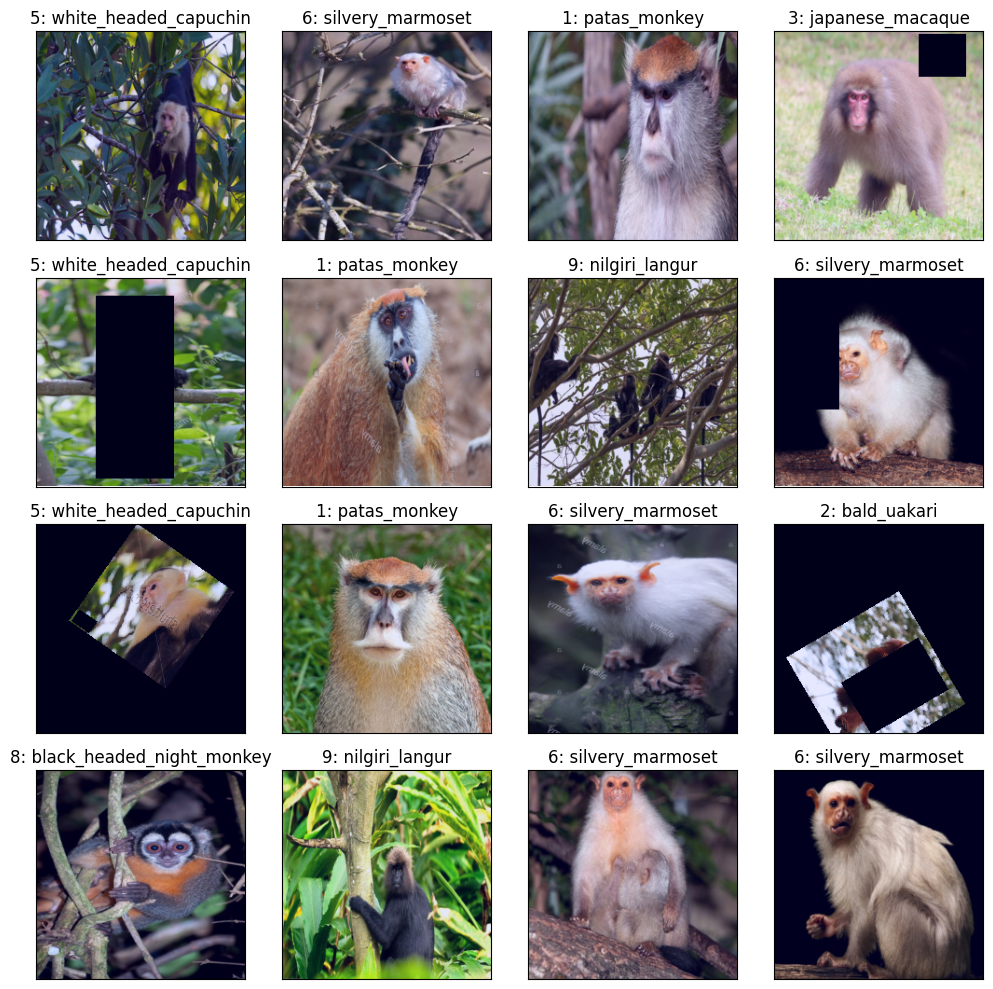

In [20]:
def visualize_images(dataloader, num_images = 20):
    fig = plt.figure(figsize=(10,10))

    #Iterate over the first batch
    images, labels = next(iter(dataloader))
    # print(images.shape)

    num_rows = 4
    num_cols = int(np.ceil((num_images / num_rows)))

    for idx in range(min(num_images, len(images))):
        image, label = images[idx], labels[idx]


        ax = fig.add_subplot(num_rows, num_cols, idx+1, xticks = [], yticks = [])

        image = image.permute(1,2,0)

        #Normalize the image to [0,1] to display

        image = (image - image.min()) / (image.max() - image.min())
        ax.imshow(image, cmap="gray")  # remove the batch dimension
        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")

    fig.tight_layout()
    plt.show()

visualize_images(train_loader, num_images = 16)

## 4. CNN Model Implementation in PyTorch

### 4.1. Define the Convolutional Blocks
Let’s start with the very first convolutional layer in the first convolutional block. To define a convolutional layer in PyTorch, we call the `nn.Conv2D()` function, which accepts several input arguments. First, we define the layer to have `32` filters. The kernel size for first filter is `5` and the subsequent layers filter is `3` (which is interpreted as `3x3`). We can use a padding option called `same`, which will pad the input tensor so that the output of the convolution operation has the same spatial size as the input. This is not required, but it’s commonly used. if you don’t explicitly specify this padding option, then the default behavior has no padding, and therefore, the spatial size of output from the convolutional layer will be slightly smaller than the input size. After each convolutional layer, we add a `BatchNorm2d` layer, which normalizes the activations of the previous layer at each batch, thereby improving the training speed and stability of the network. We use a `ReLU`  activation function in all the layers in the Network except for the output layer. This sequence of `Conv2d` followed by `BatchNorm2d` and `ReLU` is called `Conv2dNormActivation` and torchvision has a convenience function to implement this by [`torchvision.ops.Conv2dNormActivation()`](https://pytorch.org/vision/main/generated/torchvision.ops.Conv2dNormActivation.html#conv2dnormactivation).


There is also another alternative approach to specify `Conv2d` layers with [`nn.LazyConv2d()`](https://pytorch.org/docs/stable/generated/torch.nn.LazyConv2d.html#lazyconv2d) where the `input_channels` is automatically inferred from the previous `Conv2d` layers `output_channels`.

The first two convolutional layers has `32` filters each, and then we follow that with a max pooling layer that has a window size of `(2x2)`,  so the output shape from this first convolution block is `(218 x 218 x 32)`. Next, we have the second convolutional block, has `64` and `128` filters in each convolutional layer instead of `32`, and then finally, the third and fourth convolutional block has `256` and `512` filters.

**Note**: The number of filters in each convolutional layer is something that you will need to experiment with. A larger number of filters allows the model to have a greater learning capacity, but this also needs to be balanced with the amount of data available to train the model. Adding too many filters (or layers) can lead to overfitting, one of the most common issues encountered when training models.



<img src='https://www.dropbox.com/scl/fi/u3o12g52hbqkgexd2h89l/CNN-Architecure-PyTorch.png?rlkey=yqk1pwobiy82aan4qslv0kb5y&st=az71d8ti&dl=1'  align='center'>


The final layer in the feature extractor is the [`nn.AdaptiveAvgPool2d()`](https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html#adaptiveavgpool2d), which applies a 2D adaptive average pooling over an input image composed of several input channels. This layer ensures that the output has a fixed size of H x W, regardless of the input size. The number of output features is equal to the number of input channels. This is particularly useful for making the subsequent fully connected layers agnostic to the input size.

Before we define the fully connected layers for the classifier, we need to first flatten the two-dimensional activation maps that are produced by the last convolutional layer (which have a spatial shape of `3x3` with `512` channels). This is accomplished by calling the `nn.Flatten()` function to create a 1-dimensional vector of length `4608`. We then add a densely connected layer with `256` neurons and a fully connected output layer with `10` neurons because we have ten classes in our dataset.

We will show the different ways in which a `Conv2d` -> `BatchNorm` -> `ReLU`

- note: color, corner, etc. could be all extracted features.
- note: the final decision is made by classifier.
- note: softmax convert the numbers into classes.

note: It's all designer's choice to select how many layer we could have e.g. 2 convlutional laters and 1x pooling layer.
They mostly relied on the other researcher's ideas and tried to fine-tune them.

In [21]:
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self._model = nn.Sequential(

        #---------------------- Convolution Layers ----------------------

        #-----------------------------------------------
        # Conv2d Norm Activation Block1: 32 Filters, MaxPool.
        #-----------------------------------------------
        nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 5), # numbers are design choices. | 5x5 convlutional kernel.
        nn.BatchNorm2d(32), # since the output channel is 32 as well.
        nn.ReLU(inplace = True),

        nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2), # meaning that size of the image is gonna be approximately half of the original image.

        #-------------------------------------------------------------------
        # Conv2d Norm Activation Block 2: 64,128 Filters, MaxPool, Dropout(p=0.25)
        #-------------------------------------------------------------------
        nn.LazyConv2d(out_channels = 64, kernel_size = 3),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace = True),

        nn.LazyConv2d(out_channels = 128, kernel_size = 3),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2),

        #--------------------------------------------------
        # Conv2d Norm Activation Block 3: 128,256,512 Filters, MaxPool.
        #--------------------------------------------------
        Conv2dNormActivation(in_channels = 128, out_channels=256, kernel_size = 3),

        Conv2dNormActivation(in_channels = 256, out_channels=256, kernel_size = 3),
        nn.MaxPool2d(kernel_size = 2),

        Conv2dNormActivation(in_channels = 256, out_channels=512, kernel_size = 3),
        nn.MaxPool2d(kernel_size = 2),

        #---------------------- Feed Forward Layers --------------------
        nn.AdaptiveAvgPool2d(output_size=(3,3)),

        #------------------------------------
        # Flatten the convolutional features.
        #------------------------------------
        nn.Flatten(),

        #--------------------
        # Classification Head.
        #--------------------
        nn.Linear(in_features = 512*3*3, out_features = 256),
        nn.Linear(in_features = 256, out_features = 10)
    )

  def forward(self,x):
      return self._model(x)


In [22]:
model = MyModel()

optimizer  = Adam(model.parameters(), lr = train_config.learning_rate) # note: optimizer comes to update the weights.
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"

logdir = "runs/80epochs-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,224,224) # 3 for channels, 224x224 size of the image.
print(summary(model, dummy_input, row_settings = ["var_names"],device="cpu"))

Layer (type (var_name))                  Output Shape              Param #
MyModel (MyModel)                        [1, 10]                   --
├─Sequential (_model)                    [1, 10]                   --
│    └─Conv2d (0)                        [1, 32, 220, 220]         2,432
│    └─BatchNorm2d (1)                   [1, 32, 220, 220]         64
│    └─ReLU (2)                          [1, 32, 220, 220]         --
│    └─Conv2d (3)                        [1, 32, 218, 218]         9,248
│    └─BatchNorm2d (4)                   [1, 32, 218, 218]         64
│    └─ReLU (5)                          [1, 32, 218, 218]         --
│    └─MaxPool2d (6)                     [1, 32, 109, 109]         --
│    └─Conv2d (7)                        [1, 64, 107, 107]         18,496
│    └─BatchNorm2d (8)                   [1, 64, 107, 107]         128
│    └─ReLU (9)                          [1, 64, 107, 107]         --
│    └─Conv2d (10)                       [1, 128, 105, 105]        73,856


note: Conv2dNormActivation is the combination of Conv2d, BatchNorm2d, and ReLu.

- output shape
-- 1: batch number
-- 32: number of channels (filters), menaing 32 different kernels are applies to it.
-- 220x220

- note: ReLu is a very popula non-linear convlutional layer.
- note: MaxPool2d could take 2x2 neighbor region of the picture and pool them.


## 5. Model Training and Evaluation

In [23]:
def train(model, train_loader):
    model.train()
    model.to(DEVICE)

    running_loss = 0 # function of mistakes you are making (the model). | goal: loss to be low.
    correct_predictions = 0
    total_train_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"): # note: setting up the progress bar.
        images, labels = images.to(DEVICE), labels.to(DEVICE)  # sending images and labels into the device. | note: if we pass million of data instead of batched into GPU, It's gonna be overwhelmed and it's not possible.
        optimizer.zero_grad() # important
        outputs = model(images) # forward pass to the model and get the results.
        loss = F.cross_entropy(outputs, labels) # note: models are gonna make a lot of mistakes at the beginning.
        loss.backward() # backward propagation. Changing the params since we made mistakes, go and update them to not do the same next time. | GOAL: loss goes down by rnadomly select the parameters.
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1) # max probability to identify the monkey is considered.
        total_train_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    train_avg_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_predictions / total_train_samples # goes to almost zero (small value).
    return train_avg_loss, train_accuracy

In [24]:
def validation(model, val_loader):
    model.eval() # set the model in evaluation mode (not training).
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_val_samples = 0

    for images, labels in tqdm(val_loader, desc="Validation"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
             outputs = model(images)

        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, dim=1)
        total_val_samples += labels.shape[0]
        correct_predictions += (predicted == labels).sum().item()

    val_avg_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct_predictions / total_val_samples
    return val_avg_loss, val_accuracy

In [25]:
def main(model, train_loader, val_loader):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs): # go through the dataset many times.
        train_loss, train_accuracy = train(model, train_loader)
        val_loss, val_accuracy = validation(model, val_loader)


        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1:0>2}/{train_config.num_epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Logging metrics to tensorboard
        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_weights =  model.state_dict()
            print(f"Saving best model...💾")
            torch.save(best_weights, "best.pt")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [26]:
train_losses, train_accuracies, val_losses, val_accuracies = main(model, train_loader, val_loader)

Validation: 100%|██████████| 9/9 [00:06<00:00,  1.48it/s]


Epoch 01/100 - Train Loss: 1.8920, Train Accuracy: 32.63% - Val Loss: 1.7218, Val Accuracy: 42.28%
Saving best model...💾


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.38it/s]


Epoch 02/100 - Train Loss: 1.5380, Train Accuracy: 46.95% - Val Loss: 1.3453, Val Accuracy: 52.21%
Saving best model...💾


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.36it/s]


...

Epoch 98/100 - Train Loss: 0.2088, Train Accuracy: 93.07% - Val Loss: 0.8176, Val Accuracy: 83.09%


Validation: 100%|██████████| 9/9 [00:05<00:00,  1.67it/s]


Epoch 99/100 - Train Loss: 0.2237, Train Accuracy: 92.98% - Val Loss: 0.7642, Val Accuracy: 82.72%


Validation: 100%|██████████| 9/9 [00:06<00:00,  1.41it/s]

Epoch 100/100 - Train Loss: 0.2212, Train Accuracy: 92.71% - Val Loss: 0.6960, Val Accuracy: 83.09%


IMPORTANT: training accuracy increases and training loss decreases, as we go forward through the training.

We got best accuracy of **86.76%** val accuracy after training for 100 epochs.

* OUPUT:
We got best accuracy of 86.76% val accuracy after training for 100 epochs.

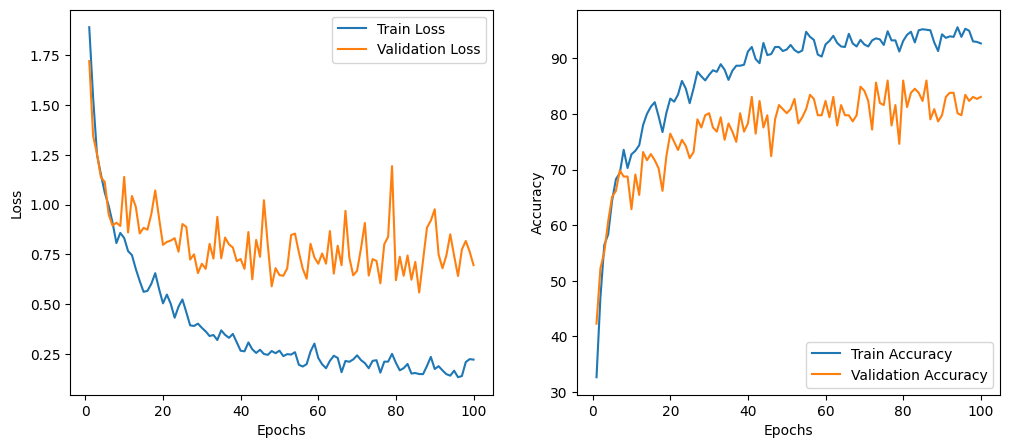

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,train_config.num_epochs + 1), train_losses, label = "Train Loss")
plt.plot(range(1, train_config.num_epochs + 1), val_losses, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,train_config.num_epochs + 1), train_accuracies, label = "Train Accuracy")
plt.plot(range(1, train_config.num_epochs + 1), val_accuracies, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

EXPECTED: training accuracy increases and training loss decreases, as we go forward through the training.

### 6. Saving and Loading Best Model Weights
Saving and loading best model weights are very convenient with `torch.save()`. This enables you to develop and train a model, save it to the file system and then load it with `torch.load()`.

In [28]:
# Load the best model weights
model.load_state_dict(torch.load("best.pt"))
model.eval()

MyModel(
  (_model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2dNormActivation(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1,

## 7. Inference

In [29]:
def prediction(model, val_loader):

    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())

We will need to denormalize our pixel values values by multiplying std and adding mean value to our image for ***Matplotlib visualization***. `np.clip` makes the pixel values to be in range of `[0,1]`

In [30]:
def denormalize(image):
    mean_ar = np.array(mean)
    std_ar = np.array(std)
    image = image * std_ar + mean_ar
    return np.clip(image, 0,1)

In [31]:
def visualise_predictions(sample_images,sample_gt_labels, pred_indices, pred_probs, num_images =5):

    fig = plt.figure(figsize = (20,5))

    for i in range(num_images):
        idx = random.randint(0, len(sample_images) -1)
        image = sample_images[idx].transpose(1,2,0) #(C,H,W) --> (H,W,C)
        label = sample_gt_labels[idx]
        pred_idx = pred_indices[idx]
        pred_prob = pred_probs[idx]

        image = denormalize(image) # when loaded we transformed the images, so now we need to do denormalization.

        ax = fig.add_subplot(1, num_images, i+1)
        ax.imshow(image)
        ax.set_title(f"GT: {class_mapping[label]}\nPred: {class_mapping[pred_idx]} ({pred_prob:.2f})")
        ax.axis('off')

    plt.show()

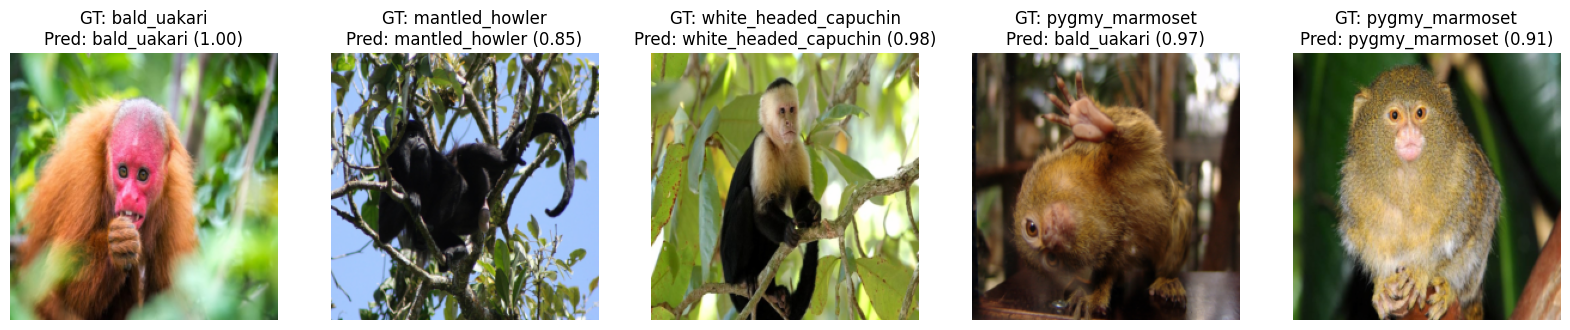

In [32]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

visualise_predictions(val_images, val_gt_labels, pred_indices, pred_probs, num_images = 5)

- GT = Ground Truth (actual value)
- Prediction

### **7.1. Confusion  matrix**

A confusion matrix is a very common metric that is used to summarize the results of a classification problem. The information is presented in the form of a table or matrix where one axis represents the ground truth labels for each class, and the other axis represents the predicted lables from the network. The entries in the table represent the number of instances from an experiment (which are sometimes represented as percentages rather than counts). Generating a confusion matrix is accomplished by calling the `confusion_matrix` from `sklearn.metrics`, which takes two required arguments which are the list of ground truth labels and the associated predicted lables.

It can be very informative to better understand where the model performs well and where it may have more difficulty.  For example, a few things stand out right away. The model does a very good job in identifying different classes even though there is probable chance of misclassifying, as it is a same species dataset. So all of these observations make intuitive sense, given the similarity of the classes involved.

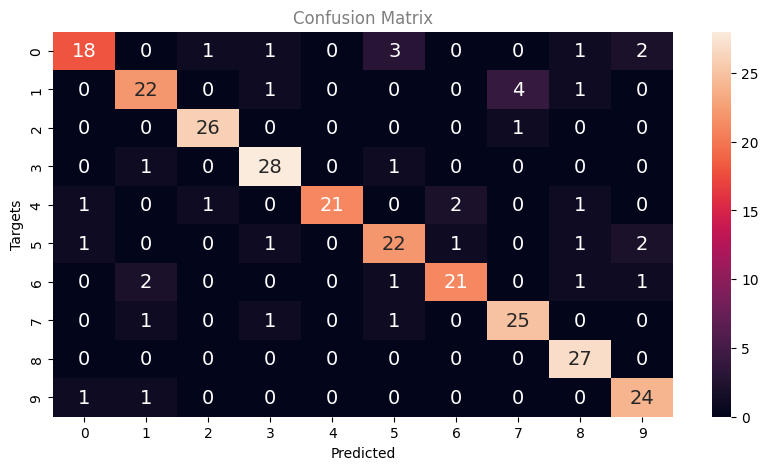

In [33]:
cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

plt.figure(figsize= [10,5])
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted")
plt.ylabel("Targets")
plt.title(f"Confusion Matrix", color="gray")
plt.show()

ex: monkye of target0 predicted as 2, 1 time.

## 8. Conclusion

In this notebook, we learned how to use PyTorch to define and train a simple convolutional neural network. We learned how to use `BatchNorm2d` layers as a regularization technique to improve the model's performance on the validation dataset. We also covered how to save and load models to and from the file system. Finally, we evaluated the model's training with a confusion matrix.

note: we never build the Neural Network from scratch. We mostly use another that already designed by other one and try to fine tune it.